
**Integrantes:**

Alejandra Ortega

Javier Cortes

Nikhil Harins

**Descripción del Dataset y Objetivo del Notebook**

Este notebook trabaja con el dataset 'ChurnData_grupoA.csv', el cual contiene información detallada sobre la rotación (churn) de clientes de un producto de servicios. El dataset incluye diversas categorías de información que abarcan:

*   **Datos Demográficos**: Como el género, si es 'SeniorCitizen', si tiene 'Partner' o 'Dependents'.
*   **Servicios Contratados**: Detalles sobre 'PhoneService', 'MultipleLines', 'InternetService' (incluyendo 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies').
*   **Información de Facturación y Contrato**: 'Contract' (tipo de contrato), 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges' y 'TotalCharges', así como la 'tenure' (permanencia) del cliente.

La columna clave en este dataset es 'Churn', que indica si el cliente ha cancelado el servicio (Yes/No), y es la **variable objetivo** principal para nuestro análisis.

El objetivo fundamental de este notebook es **analizar y predecir la rotación de clientes (churn)** utilizando los datos proporcionados. Para lograrlo, el proceso se centrará en:

1.  **Preprocesamiento de Datos**: Limpieza y preparación de las variables para el análisis.
2.  **Ingeniería de Variables**: Creación de nuevas características a partir de las existentes para mejorar la capacidad predictiva.
3.  **Análisis de Correlación**: Identificación de las variables más influyentes en el 'churn' para comprender los factores que impulsan la decisión de los clientes de abandonar el servicio.

En resumen, buscaremos entender por qué los clientes se van y construir un modelo que pueda anticipar esta situación.

---
###Carga y Exploración del Dataset

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
# Importamos todas las librerías que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from google.colab import files
warnings.filterwarnings('ignore')

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (mean_squared_error, accuracy_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

# Configuración visual global
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("husl")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


---
###Carga del data set

In [ ]:
from google.colab import files


# Carga del archivo
upload_file = files.upload()


# Ver los archivos subidos
for filename in upload_file.keys():
    print(f'Archivo subido: {filename}')

Saving ChurnData_grupoA.csv to ChurnData_grupoA (1).csv
Archivo subido: ChurnData_grupoA (1).csv


In [ ]:
#Leer el archivo
Churn = pd.read_csv('ChurnData_grupoA.csv', sep=',',decimal='.')
Churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6574-MCOEH,Female,0,Yes,Yes,33,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,79.15,2531.4,No
1,7399-QHBJS,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Credit card (automatic),66.75,4760.3,No
2,3049-SOLAY,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.20,292.85,Yes
3,0997-YTLNY,Female,0,No,Yes,19,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,No,Mailed check,48.80,953.65,No
4,3317-HRTNN,Female,1,No,No,5,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,45.70,198,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
1759,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
1760,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
1761,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


---
##Preprocesamiento

In [ ]:
# Detección de valores nulos
Churn.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1759,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1760,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1761,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Numero de valores nulos
Churn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Estadísticos básicos sobre el data set
Churn.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,1763.0,0.163925,0.370313,0.00,0.00,0.00,0.000,1.0
tenure,1763.0,32.602382,24.433679,0.00,9.00,30.00,55.000,72.0
MonthlyCharges,1763.0,64.394952,29.833516,18.55,35.75,70.15,89.425,118.2


In [ ]:
#Revisamos el tipo de dato de cada variable
Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1763 entries, 0 to 1762
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1763 non-null   object 
 1   gender            1763 non-null   object 
 2   SeniorCitizen     1763 non-null   int64  
 3   Partner           1763 non-null   object 
 4   Dependents        1763 non-null   object 
 5   tenure            1763 non-null   int64  
 6   PhoneService      1763 non-null   object 
 7   MultipleLines     1763 non-null   object 
 8   InternetService   1763 non-null   object 
 9   OnlineSecurity    1763 non-null   object 
 10  OnlineBackup      1763 non-null   object 
 11  DeviceProtection  1763 non-null   object 
 12  TechSupport       1763 non-null   object 
 13  StreamingTV       1763 non-null   object 
 14  StreamingMovies   1763 non-null   object 
 15  Contract          1763 non-null   object 
 16  PaperlessBilling  1763 non-null   object 


In [ ]:
# Pasar de string a numérico (Total Charges es numérico y en la base se lee como object)
# Primero, reemplazamos los espacios en blanco por NaN para que pandas los reconozca como nulos.
Churn['TotalCharges'] = Churn['TotalCharges'].replace(' ', np.nan)
Churn['TotalCharges'] = pd.to_numeric(Churn['TotalCharges'], errors='coerce')
Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1763 entries, 0 to 1762
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1763 non-null   object 
 1   gender            1763 non-null   object 
 2   SeniorCitizen     1763 non-null   int64  
 3   Partner           1763 non-null   object 
 4   Dependents        1763 non-null   object 
 5   tenure            1763 non-null   int64  
 6   PhoneService      1763 non-null   object 
 7   MultipleLines     1763 non-null   object 
 8   InternetService   1763 non-null   object 
 9   OnlineSecurity    1763 non-null   object 
 10  OnlineBackup      1763 non-null   object 
 11  DeviceProtection  1763 non-null   object 
 12  TechSupport       1763 non-null   object 
 13  StreamingTV       1763 non-null   object 
 14  StreamingMovies   1763 non-null   object 
 15  Contract          1763 non-null   object 
 16  PaperlessBilling  1763 non-null   object 


In [ ]:
#Se cuentan cuantos valores nulos hay en todas las columnas
Churn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Matriz de correlación
Churn.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.030353,0.222603
tenure,0.030353,1.000000,0.254369
MonthlyCharges,0.222603,0.254369,1.000000


---
###Copia del Dataframe como buena práctica, esto garantiza la integridad de la base de datos inicial.

In [ ]:
#Creamos una copia del archivo para no afectar la base de datos incial.
Churn_copy = Churn.copy()

# Rellenar los 2 nulos conocidos en 'TotalCharges' con la mediana
mediana_total_charges = Churn_copy['TotalCharges'].median()
print(f"Mediana calculada de TotalCharges: {mediana_total_charges}")

# Churn_copy['TotalCharges'].fillna(median_total_charges, inplace=True)
Churn_copy['TotalCharges'] = Churn_copy['TotalCharges'].fillna(mediana_total_charges)
print("Nulos en TotalCharges después del relleno:", Churn_copy['TotalCharges'].isnull().sum())
Churn_copy['TotalCharges'].head()
# Mostrar las filas donde se rellenaron los valores nulos (índices de los 2 nulos que fueron rellenados)
# Filtramos las filas donde TotalCharges es igual a la mediana que acabamos de usar
print(f"\nFilas donde se rellenaron los nulos con la mediana ({mediana_total_charges}):")
display(Churn_copy[Churn_copy['TotalCharges'] == mediana_total_charges].head(2))

Mediana calculada de TotalCharges: 1383.6
Nulos en TotalCharges después del relleno: 0

Filas donde se rellenaron los nulos con la mediana (1383.6):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
321,2877-VDUER,Female,0,Yes,Yes,35,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,No,Mailed check,40.90,1383.6,No
1390,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,1383.6,No


In [ ]:
#Verificamos que ya no hayan valores nulos
Churn_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#Validamos registros unicos en cada variable
Churn_copy.nunique()

,0
customerID,1763
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
# Identificar columnas categóricas con más de dos valores únicos para One Hot Encoding
# Excluyendo 'customerID' ya que es un identificador único y no una característica categórica para codificar.
# 'tenure', 'MonthlyCharges', 'TotalCharges' ya son numéricas.
categorical_cols_to_encode = [
    col for col in Churn_copy.columns
    if Churn_copy[col].dtype == 'object'
    and Churn_copy[col].nunique() > 1
    and col != 'customerID'
]

print(f"Columnas a codificar con One Hot Encoding: {categorical_cols_to_encode}")

# Aplicar One Hot Encoding a las columnas identificadas
Churn_encoded = pd.get_dummies(Churn_copy, columns=categorical_cols_to_encode, drop_first=False)

# Mostrar las primeras filas del DataFrame con las nuevas columnas
display(Churn_encoded.head())

# Mostrar la forma del nuevo DataFrame para ver el aumento en el número de columnas
print(f"Dimensiones del DataFrame después del One Hot Encoding: {Churn_encoded.shape}")

Columnas a codificar con One Hot Encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,6574-MCOEH,0,33,79.15,2531.40,True,False,False,True,False,...,True,False,False,True,False,False,True,False,True,False
1,7399-QHBJS,0,72,66.75,4760.30,True,False,False,True,False,...,False,True,True,False,False,True,False,False,True,False
2,3049-SOLAY,0,3,95.20,292.85,True,False,False,True,True,...,False,False,False,True,False,False,True,False,False,True
3,0997-YTLNY,0,19,48.80,953.65,True,False,True,False,False,...,False,False,True,False,False,False,False,True,True,False
4,3317-HRTNN,1,5,45.70,198.00,True,False,True,False,True,...,False,False,True,False,False,False,True,False,False,True


Dimensiones del DataFrame después del One Hot Encoding: (1763, 48)


---
###Analisis de correlación

In [ ]:
# Matriz de correlación con las variables numéricas
Churn_copy.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.030353,0.222603,0.110954
tenure,0.030353,1.000000,0.254369,0.830975
MonthlyCharges,0.222603,0.254369,1.000000,0.652784
TotalCharges,0.110954,0.830975,0.652784,1.000000


In [ ]:
# Se encuentran las correlaciones de Churn_Yes con respecto a todas las columnas (variables) numericas
abs(Churn_encoded.corr(numeric_only=True)['Churn_Yes']).sort_values(ascending=False)


,Churn_Yes
Churn_No,1.000000
Churn_Yes,1.000000
Contract_Month-to-month,0.419486
tenure,0.361421
OnlineSecurity_No,0.339931
InternetService_Fiber optic,0.304378
Contract_Two year,0.302933
TechSupport_No,0.299874
PaymentMethod_Electronic check,0.280617
OnlineBackup_No,0.264379


In [ ]:
# Se encuentran las correlaciones de Churn_No con respecto a todas las columnas (variables) numericas
abs(Churn_encoded.corr(numeric_only=True)['Churn_No']).sort_values(ascending=False)


,Churn_No
Churn_Yes,1.000000
Churn_No,1.000000
Contract_Month-to-month,0.419486
tenure,0.361421
OnlineSecurity_No,0.339931
InternetService_Fiber optic,0.304378
Contract_Two year,0.302933
TechSupport_No,0.299874
PaymentMethod_Electronic check,0.280617
OnlineBackup_No,0.264379


In [ ]:
# Calcular las correlaciones de todas las columnas con 'Churn_Yes'
correlations_with_churn = Churn_encoded.corr(numeric_only=True)['Churn_Yes'].abs().sort_values(ascending=False)

# Definir un umbral de correlación (por ejemplo, 0.1) para incluir variables en el heatmap
# Puedes ajustar este umbral según lo que consideres 'baja correlación'
correlation_threshold = 0.1

# Seleccionar las variables que tienen una correlación absoluta mayor que el umbral
# Excluimos Churn_Yes y Churn_No de la lista de filtrado si queremos ver su correlación con otras variables
high_correlation_features = correlations_with_churn[correlations_with_churn > correlation_threshold].index.tolist()

# Asegurarse de que 'Churn_Yes' esté incluida en la lista de características si no lo está ya
if 'Churn_Yes' not in high_correlation_features:
    high_correlation_features.append('Churn_Yes')

# Filtrar la matriz de correlación original para incluir solo estas características
filtered_corr = Churn_encoded[high_correlation_features].corr(numeric_only=True)

print(f"Variables seleccionadas (correlación absoluta > {correlation_threshold} con Churn_Yes):\n{high_correlation_features}")

Variables seleccionadas (correlación absoluta > 0.1 con Churn_Yes):
['Churn_No', 'Churn_Yes', 'Contract_Month-to-month', 'tenure', 'OnlineSecurity_No', 'InternetService_Fiber optic', 'Contract_Two year', 'TechSupport_No', 'PaymentMethod_Electronic check', 'OnlineBackup_No', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'StreamingTV_No internet service', 'OnlineSecurity_No internet service', 'TechSupport_No internet service', 'StreamingMovies_No internet service', 'InternetService_No', 'OnlineBackup_No internet service', 'TotalCharges', 'MonthlyCharges', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'Contract_One year', 'OnlineSecurity_Yes', 'Dependents_No', 'Dependents_Yes', 'SeniorCitizen', 'Partner_Yes', 'Partner_No', 'StreamingMovies_No', 'TechSupport_Yes', 'InternetService_DSL', 'StreamingTV_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)']


---
###Mapa de calor
Ahora, visualizaremos el mapa de calor con las variables filtradas para enfocarnos en las correlaciones más fuertes con 'Churn'.

Columnas identificadas para eliminación debido a alta correlación (> 0.85): ['PaperlessBilling_Yes', 'TechSupport_No internet service', 'Dependents_Yes', 'Churn_No', 'OnlineSecurity_No internet service', 'gender_Male', 'StreamingMovies_No internet service', 'OnlineBackup_No internet service', 'PhoneService_Yes', 'StreamingTV_No internet service', 'DeviceProtection_No internet service', 'Partner_Yes', 'MultipleLines_No phone service']


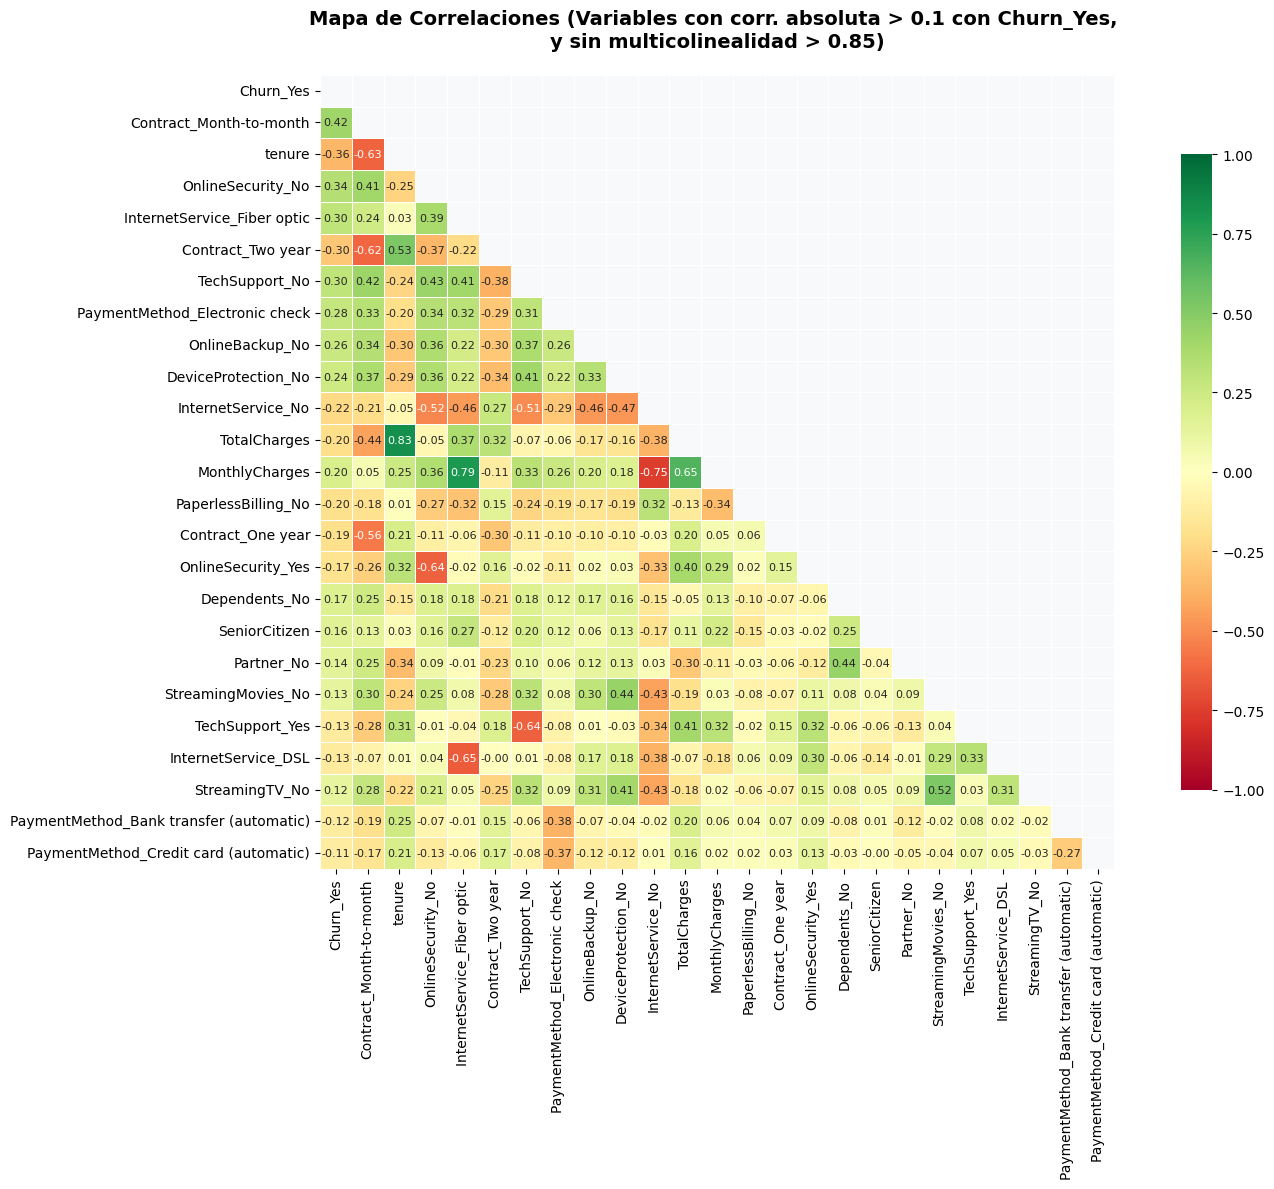


Clave de lectura:
Verde oscuro: Correlación positiva fuerte (cercana a +1)
Rojo oscuro: Correlación negativa fuerte (cercana a -1)
Amarillo/Blanco: Poca o ninguna correlación (cercano a 0)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Asumimos que Churn_encoded ya está definido a partir de pasos anteriores en el notebook.
# Calcula la matriz de correlación completa en valor absoluto.
corr_matrix_full = Churn_encoded.corr(numeric_only=True).abs()

umbral_alta_correlacion = 0.85

# Conjunto para almacenar las columnas a eliminar debido a alta multicolinealidad.
# La lógica se asegura de no eliminar la variable objetivo 'Churn_Yes'.
columns_to_drop_from_high_corr_refined = set()

# Itera sobre el triángulo superior de la matriz de correlación.
# Esto evita duplicados (corr(A,B) vs corr(B,A)) y auto-correlaciones (corr(A,A)).
for i in range(len(corr_matrix_full.columns)):
    for j in range(i + 1, len(corr_matrix_full.columns)):
        col1 = corr_matrix_full.columns[i]
        col2 = corr_matrix_full.columns[j]

        if corr_matrix_full.loc[col1, col2] > umbral_alta_correlacion:
            # Priorizamos mantener 'Churn_Yes'.
            # Si col2 es 'Churn_Yes', se añade col1 a la lista para eliminar.
            if col2 == 'Churn_Yes':
                columns_to_drop_from_high_corr_refined.add(col1)
            # Si col1 es 'Churn_Yes' (y col2 no lo es), se añade col2 a la lista para eliminar.
            elif col1 == 'Churn_Yes':
                columns_to_drop_from_high_corr_refined.add(col2)
            else:
                # Para otras pares de variables altamente correlacionadas (ni col1 ni col2 son 'Churn_Yes'),
                # se elimina arbitrariamente la segunda columna (col2) para reducir la multicolinealidad.
                columns_to_drop_from_high_corr_refined.add(col2)

print(f"Columnas identificadas para eliminación debido a alta correlación (> {umbral_alta_correlacion}): {list(columns_to_drop_from_high_corr_refined)}")

# Crear un nuevo DataFrame eliminando las columnas identificadas.
# 'errors="ignore"' evita errores si alguna columna ya fue eliminada o no existe.
Churn_reduced_multicollinearity = Churn_encoded.drop(columns=list(columns_to_drop_from_high_corr_refined), errors='ignore')

# Verificar que 'Churn_Yes' aún esté presente antes de continuar.
if 'Churn_Yes' in Churn_reduced_multicollinearity.columns:
    # Recalcular las correlaciones de las columnas restantes con 'Churn_Yes'.
    correlations_with_churn_reduced = Churn_reduced_multicollinearity.corr(numeric_only=True)['Churn_Yes'].abs().sort_values(ascending=False)

    # Definir el umbral de correlación para la visualización del heatmap (por ejemplo, 0.1).
    correlation_threshold_heatmap = 0.1

    # Seleccionar solo las características cuya correlación absoluta con 'Churn_Yes' supera el umbral del heatmap.
    high_correlation_features_for_heatmap = correlations_with_churn_reduced[correlations_with_churn_reduced > correlation_threshold_heatmap].index.tolist()

    # Asegurarse de que 'Churn_Yes' esté incluida en la lista de características para el heatmap.
    if 'Churn_Yes' not in high_correlation_features_for_heatmap:
        high_correlation_features_for_heatmap.append('Churn_Yes')

    # Filtrar el DataFrame reducido para construir la matriz de correlación final para el heatmap.
    filtered_corr_final = Churn_reduced_multicollinearity[high_correlation_features_for_heatmap].corr(numeric_only=True)

    # Generar el mapa de calor.
    fig, ax = plt.subplots(figsize=(16, 12))

    # Crear una máscara para mostrar solo el triángulo inferior del mapa de calor.
    mask = np.triu(np.ones_like(filtered_corr_final, dtype=bool))

    sns.heatmap(filtered_corr_final,
                mask=mask,
                annot=True,
                fmt='.2f',
                cmap='RdYlGn',
                center=0,
                vmin=-1, vmax=1,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                ax=ax,
                annot_kws={"size": 8})

    ax.set_title(f'Mapa de Correlaciones (Variables con corr. absoluta > {correlation_threshold_heatmap} con Churn_Yes, \ny sin multicolinealidad > {umbral_alta_correlacion})', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    print()
    print("Clave de lectura:")
    print("Verde oscuro: Correlación positiva fuerte (cercana a +1)")
    print("Rojo oscuro: Correlación negativa fuerte (cercana a -1)")
    print("Amarillo/Blanco: Poca o ninguna correlación (cercano a 0)")
elif 'Churn_Yes' not in Churn_encoded.columns:
    print("Error: La columna 'Churn_Yes' no se encuentra en el DataFrame original 'Churn_encoded'. Por favor, verifica el paso de codificación.")
else:
    print("Error inesperado: 'Churn_Yes' fue eliminado del DataFrame. Revisa la lógica de eliminación de multicolinealidad.")


---
###Calculo de los mejores regresores

Los mejores regresores son aquellas variables con mayor correlación (en valor absoluto) con la variable a predecir (Churn_yes).

Vamos a calcular los mejores 5 y 8 regresores para el modelo.

In [ ]:
# Utilizar las correlaciones ya calculadas y almacenadas en 'correlations_with_churn_reduced',
# las cuales se generaron después de la reducción de multicolinealidad.
# Seleccionar las 5 variables principales por correlación con 'Churn_Yes',
# excluyendo 'Churn_Yes' de la lista de características predictivas.
top_5_variables = correlations_with_churn_reduced[~correlations_with_churn_reduced.index.isin(['Churn_Yes'])].head(5)

print("Top 5 Variables para el Modelo Predictivo (más correlacionadas con Churn_Yes):")
print("=" * 80)
print(top_5_variables)

# Crear el conjunto de datos con las 5 características principales más la variable objetivo
top_5_features = top_5_variables.index.tolist()
print(f"\nCaracterísticas seleccionadas: {top_5_features}")

# Preparar los datos (X e y) usando las características seleccionadas
# Estas deben venir del DataFrame 'Churn_reduced_multicollinearity'.
X = Churn_reduced_multicollinearity[top_5_features]
y = Churn_reduced_multicollinearity['Churn_Yes']

print(f"\nDimensiones de la matriz de características (X): {X.shape}")
print(f"Dimensiones de la variable objetivo (y): {y.shape}")
print(f"\nNombres de las características en X:\n{X.columns.tolist()}")

Top 5 Variables para el Modelo Predictivo (más correlacionadas con Churn_Yes):
Contract_Month-to-month        0.419486
tenure                         0.361421
OnlineSecurity_No              0.339931
InternetService_Fiber optic    0.304378
Contract_Two year              0.302933
Name: Churn_Yes, dtype: float64

Características seleccionadas: ['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No', 'InternetService_Fiber optic', 'Contract_Two year']

Dimensiones de la matriz de características (X): (1763, 5)
Dimensiones de la variable objetivo (y): (1763,)

Nombres de las características en X:
['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No', 'InternetService_Fiber optic', 'Contract_Two year']


In [ ]:
# Utilizar las correlaciones ya calculadas y almacenadas en 'correlations_with_churn_reduced',
# las cuales se generaron después de la reducción de multicolinealidad.
# Seleccionar las 8 variables principales por correlación con 'Churn_Yes',
# excluyendo 'Churn_Yes' de la lista de características predictivas.
top_8_variables = correlations_with_churn_reduced[~correlations_with_churn_reduced.index.isin(['Churn_Yes'])].head(8)

print("Top 8 Variables para el Modelo Predictivo (más correlacionadas con Churn_Yes):")
print("=" * 80)
print(top_8_variables)

# Crear el conjunto de datos con las 8 características principales más la variable objetivo
top_8_features = top_8_variables.index.tolist()
print(f"\nCaracterísticas seleccionadas: {top_8_features}")

# Preparar los datos (X e y) usando las características seleccionadas
# Estas deben venir del DataFrame 'Churn_reduced_multicollinearity'.
X = Churn_reduced_multicollinearity[top_8_features]
y = Churn_reduced_multicollinearity['Churn_Yes']

print(f"\nDimensiones de la matriz de características (X): {X.shape}")
print(f"Dimensiones de la variable objetivo (y): {y.shape}")
print(f"\nNombres de las características en X:\n{X.columns.tolist()}")

Top 8 Variables para el Modelo Predictivo (más correlacionadas con Churn_Yes):
Contract_Month-to-month           0.419486
tenure                            0.361421
OnlineSecurity_No                 0.339931
InternetService_Fiber optic       0.304378
Contract_Two year                 0.302933
TechSupport_No                    0.299874
PaymentMethod_Electronic check    0.280617
OnlineBackup_No                   0.264379
Name: Churn_Yes, dtype: float64

Características seleccionadas: ['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No', 'InternetService_Fiber optic', 'Contract_Two year', 'TechSupport_No', 'PaymentMethod_Electronic check', 'OnlineBackup_No']

Dimensiones de la matriz de características (X): (1763, 8)
Dimensiones de la variable objetivo (y): (1763,)

Nombres de las características en X:
['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No', 'InternetService_Fiber optic', 'Contract_Two year', 'TechSupport_No', 'PaymentMethod_Electronic check', 'OnlineBackup_No']


---
## Modelado: Creación de Modelos de Clasificación con Diferentes Splits

En esta sección, prepararemos los datos para el modelado, dividiéndolos en conjuntos de entrenamiento y prueba con dos proporciones distintas: 40% para entrenamiento / 60% para prueba y 75% para entrenamiento / 25% para prueba. Luego, entrenaremos y evaluaremos con el modelo `GradientBoostingClassifier` de clasificación para cada split.

In [ ]:
# Definir las características (X) y la variable objetivo (y)
# Excluimos 'customerID' porque es un identificador, y 'Churn_No' porque es redundante con 'Churn_Yes'.

# X debe contener todas las características predictivas, excluyendo el 'customerID' y la variable objetivo 'Churn_Yes'.
# Churn_No también debe ser excluido si está presente, ya que es redundante con Churn_Yes.
columns_to_exclude_from_X = ['customerID', 'Churn_Yes']
if 'Churn_No' in Churn_reduced_multicollinearity.columns:
    columns_to_exclude_from_X.append('Churn_No')

X = Churn_reduced_multicollinearity.drop(columns=columns_to_exclude_from_X, errors='ignore')

# y es la variable objetivo, que es 'Churn_Yes'.
y = Churn_reduced_multicollinearity['Churn_Yes']

print("Datos preparados para el modelado.")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Datos preparados para el modelado.
Dimensiones de X: (1763, 33)
Dimensiones de y: (1763,)


---
### Split 1: Entrenamiento 60% / Prueba 40% (Utilizando Churn_reduced_multicollinearity)

In [ ]:
X_filtered = Churn_reduced_multicollinearity.drop(columns=['customerID', 'Churn_No', 'Churn_Yes'], errors='ignore')
y_filtered = Churn_reduced_multicollinearity['Churn_Yes']

# Asegurarse de que no haya valores infinitos o NaN en X_filtered
X_filtered = X_filtered.replace([np.inf, -np.inf], np.nan).fillna(0)

# Split 1: 40% entrenamiento, 60% prueba
X_train_40, X_test_60_new, y_train_40, y_test_60_new = train_test_split(
    X_filtered, y_filtered,
    test_size=0.60,
    random_state=42,
    stratify=y_filtered
)

print(f"Dimensiones del split 40/60:")
print(f"  X_train: {X_train_40.shape}, y_train: {y_train_40.shape}")
print(f"  X_test: {X_test_60_new.shape}, y_test: {y_test_60_new.shape}")

# --- Modelo 1: GradientBoostingClassifier (Split 40/60) ---
print("\n--- Entrenando GradientBoostingClassifier (Split 40/60) ---")
gbc_model_40 = GradientBoostingClassifier(random_state=42)
gbc_model_40.fit(X_train_40, y_train_40)
y_pred_gbc_40 = gbc_model_40.predict(X_test_60_new)

print("\nMétricas para GradientBoostingClassifier (Split 40/60):")
print(f"Accuracy: {accuracy_score(y_test_60_new, y_pred_gbc_40):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_60_new, y_pred_gbc_40))
print("Classification Report:\n", classification_report(y_test_60_new, y_pred_gbc_40))

Dimensiones del split 40/60:
  X_train: (705, 33), y_train: (705,)
  X_test: (1058, 33), y_test: (1058,)

--- Entrenando GradientBoostingClassifier (Split 40/60) ---

Métricas para GradientBoostingClassifier (Split 40/60):
Accuracy: 0.7665
Confusion Matrix:
 [[693  73]
 [174 118]]
Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.90      0.85       766
        True       0.62      0.40      0.49       292

    accuracy                           0.77      1058
   macro avg       0.71      0.65      0.67      1058
weighted avg       0.75      0.77      0.75      1058



---
### Split 2: Entrenamiento 75% / Prueba 25% (Utilizando Churn_reduced_multicollinearity)

In [ ]:
X_filtered = Churn_reduced_multicollinearity.drop(columns=['customerID', 'Churn_No', 'Churn_Yes'], errors='ignore')
y_filtered = Churn_reduced_multicollinearity['Churn_Yes']

# Asegurarse de que no haya valores infinitos o NaN en X_filtered
X_filtered = X_filtered.replace([np.inf, -np.inf], np.nan).fillna(0)

# Split 2: 75% entrenamiento, 25% prueba
X_train_75, X_test_25_new, y_train_75, y_test_25_new = train_test_split(
    X_filtered, y_filtered,
    test_size=0.25,
    random_state=42,
    stratify=y_filtered
)

print(f"Dimensiones del split 75/25:")
print(f"  X_train: {X_train_75.shape}, y_train: {y_train_75.shape}")
print(f"  X_test: {X_test_25_new.shape}, y_test: {y_test_25_new.shape}")

# --- Modelo 2: GradientBoostingClassifier (Split 75/25) ---
print("\n--- Entrenando GradientBoostingClassifier (Split 75/25) ---")
gbc_model_75 = GradientBoostingClassifier(random_state=42)
gbc_model_75.fit(X_train_75, y_train_75)
y_pred_gbc_75 = gbc_model_75.predict(X_test_25_new)

print("\nMétricas para GradientBoostingClassifier (Split 40/60):")
print(f"Accuracy: {accuracy_score(y_test_25_new, y_pred_gbc_75):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_25_new, y_pred_gbc_75))
print("Classification Report:\n", classification_report(y_test_25_new, y_pred_gbc_75))

Dimensiones del split 75/25:
  X_train: (1322, 33), y_train: (1322,)
  X_test: (441, 33), y_test: (441,)

--- Entrenando GradientBoostingClassifier (Split 75/25) ---

Métricas para GradientBoostingClassifier (Split 40/60):
Accuracy: 0.7778
Confusion Matrix:
 [[282  37]
 [ 61  61]]
Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.88      0.85       319
        True       0.62      0.50      0.55       122

    accuracy                           0.78       441
   macro avg       0.72      0.69      0.70       441
weighted avg       0.77      0.78      0.77       441



---
##Visualización de los Splits de Datos

Para entender mejor cómo se dividieron los datos, presentamos dos visualizaciones que muestran las proporciones de los conjuntos de entrenamiento y prueba para cada escenario.

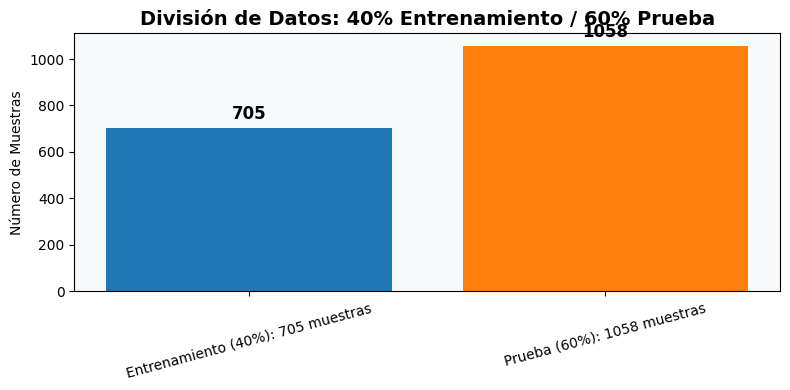

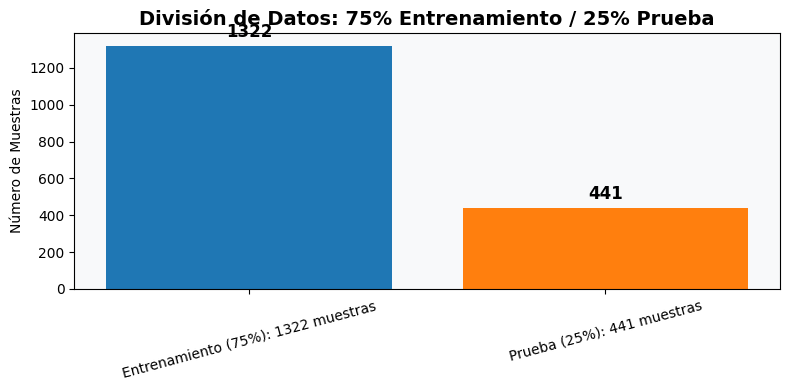

In [ ]:
## VISUALIZACIÓN: TRAIN vs TEST — LA DIFERENCIA CLAVE
import matplotlib.pyplot as plt
import seaborn as sns

def plot_data_split(train_size, test_size, train_label, test_label, title):
    sizes = [train_size, test_size]
    labels = [f'{train_label}: {train_size} muestras', f'{test_label}: {test_size} muestras']
    colors = ['#1f77b4', '#ff7f0e'] # Azul para train, Naranja para test

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, sizes, color=colors)

    # Añadir el número de muestras en cada barra
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (max(sizes) * 0.02), round(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_ylabel('Número de Muestras')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

# --- Visualización para Split 60/40 (renombrado de la anterior 40/60) ---
# Usamos X_train_60 y X_test_40_new definidos en celda e3440675
train_40_count = X_train_40.shape[0]
test_60_new_count = X_test_60_new.shape[0]
plot_data_split(train_40_count, test_60_new_count, 'Entrenamiento (40%)', 'Prueba (60%)', 'División de Datos: 40% Entrenamiento / 60% Prueba')

# --- Visualización para Split 75/25 ---
# Usamos X_train_75 y X_test_25 definidos en celda f892da36
train_75_count = X_train_75.shape[0]
test_25_count = X_test_25_new.shape[0]
plot_data_split(train_75_count, test_25_count, 'Entrenamiento (75%)', 'Prueba (25%)', 'División de Datos: 75% Entrenamiento / 25% Prueba')

##Comparativa de Accuracy: Entrenamiento vs. Prueba

In [ ]:
# Calcular la precisión de entrenamiento para todos los modelos

# GBC 40/60 Split
y_train_pred_gbc_40 = gbc_model_40.predict(X_train_40)
acc_train_gbc_40 = accuracy_score(y_train_40, y_train_pred_gbc_40)

# GBC 75/25 Split
y_train_pred_gbc_75 = gbc_model_75.predict(X_train_75)
acc_train_gbc_75 = accuracy_score(y_train_75, y_train_pred_gbc_75)

# Recopilar las métricas en un DataFrame para facilitar la visualización
accuracy_data = {
    'Modelo': [
        'GBC (40/60 Split)', 'GBC (40/60 Split)',
        'GBC (75/25 Split)', 'GBC (75/25 Split)'
    ],
    'Conjunto': [
        'Entrenamiento', 'Prueba',
        'Entrenamiento', 'Prueba'
    ],
    'Accuracy': [
        acc_train_gbc_40, accuracy_score(y_test_60_new, y_pred_gbc_40),
        acc_train_gbc_75, accuracy_score(y_test_25_new, y_pred_gbc_75)
    ]
}

df_accuracy = pd.DataFrame(accuracy_data)
display(df_accuracy)

,Modelo,Conjunto,Accuracy
0,GBC (40/60 Split),Entrenamiento,0.924823
1,GBC (40/60 Split),Prueba,0.766541
2,GBC (75/25 Split),Entrenamiento,0.879728
3,GBC (75/25 Split),Prueba,0.777778


---
##Graficas para evidenciar el accurrency

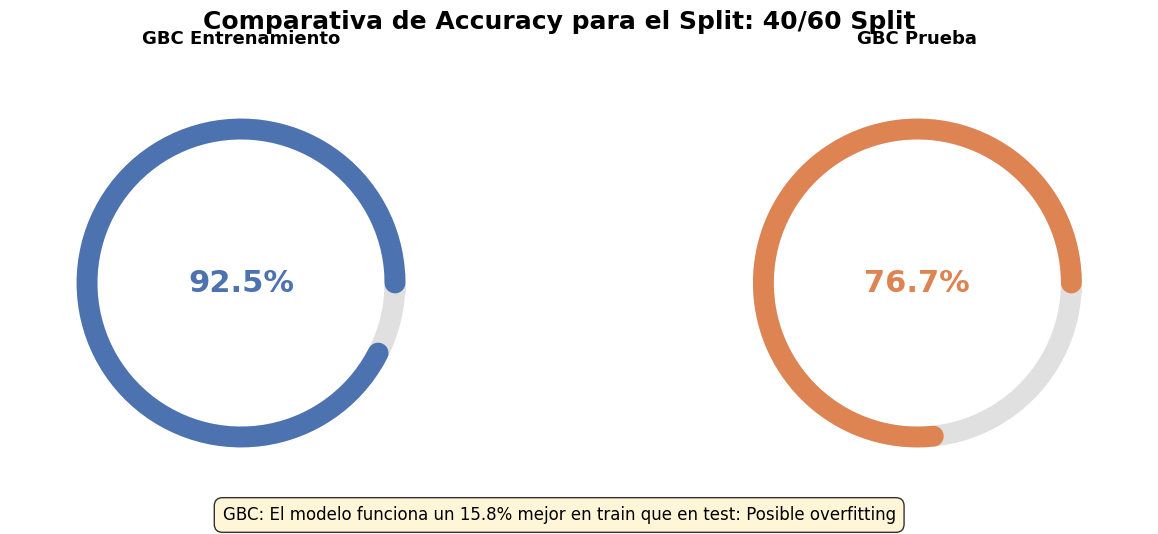

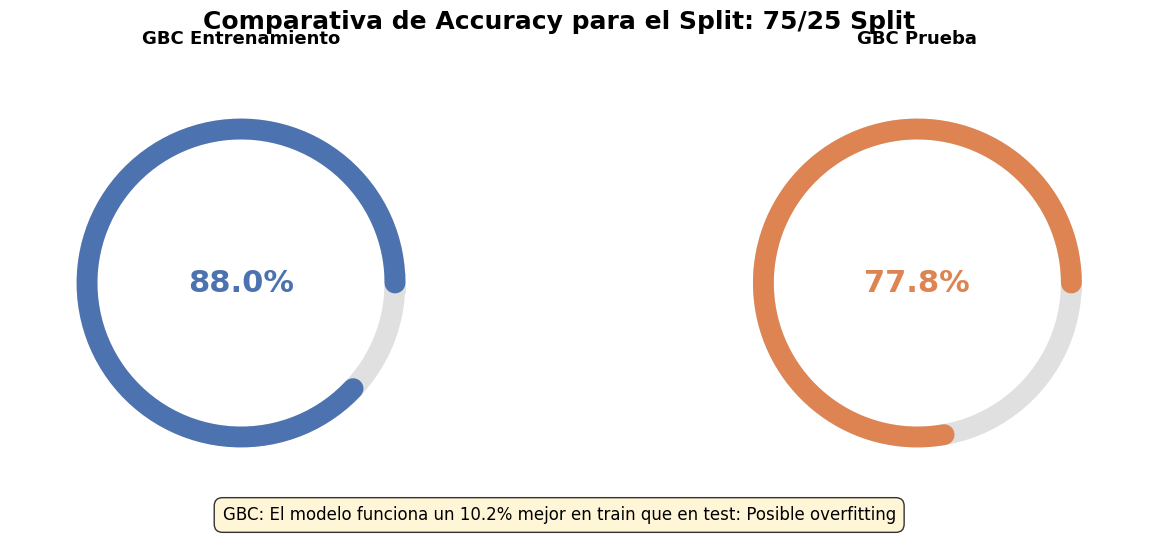

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Función auxiliar para dibujar un único medidor circular
def _draw_gauge(ax, value, color, label):
    theta = np.linspace(0, 2*np.pi*value/100, 100)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=15, color=color, solid_capstyle='round')
    ax.plot(np.cos(np.linspace(0, 2*np.pi, 100)),
            np.sin(np.linspace(0, 2*np.pi, 100)), linewidth=15, color='#e0e0e0', zorder=0)
    ax.text(0, 0, f'{value:.1f}%', ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(label, fontsize=13, fontweight='bold')

# Función principal para trazar la comparación de precisión para un split, combinando ambos modelos
def plot_split_accuracy_comparison(df_accuracy, split_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Comparativa de Accuracy para el Split: {split_name}', fontsize=18, fontweight='bold', y=0.95)

    colors_train = '#4C72B0' # Azul para train
    colors_test = '#DD8452'  # Naranja para test

    # --- GradientBoostingClassifier ---
    gbc_data = df_accuracy[df_accuracy['Modelo'] == f'GBC ({split_name})']
    acc_train_gbc = gbc_data[gbc_data['Conjunto'] == 'Entrenamiento']['Accuracy'].iloc[0] * 100
    acc_test_gbc = gbc_data[gbc_data['Conjunto'] == 'Prueba']['Accuracy'].iloc[0] * 100

    _draw_gauge(axes[0], acc_train_gbc, colors_train, 'GBC Entrenamiento')
    _draw_gauge(axes[1], acc_test_gbc, colors_test, 'GBC Prueba')

    diferencia_gbc = (acc_train_gbc - acc_test_gbc) / 100
    msg_gbc = ""
    if diferencia_gbc > 0.05:
        msg_gbc = f"GBC: El modelo funciona un {diferencia_gbc*100:.1f}% mejor en train que en test: Posible overfitting"
    elif diferencia_gbc < 0:
        msg_gbc = f"GBC: El modelo funciona de forma similar en train y test: Buena generalización"
    else:
        msg_gbc = f"GBC: El modelo generaliza bien (diferencia de {diferencia_gbc*100:.1f}%)"

    # Posicionar mensaje debajo de los medidores GBC
    fig.text(0.5, 0.1, msg_gbc, ha='center', fontsize=12,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', alpha=0.8), transform=fig.transFigure)

# Iterar sobre los tipos de split únicos y generar un gráfico combinado para cada uno
for split_type in ['40/60 Split', '75/25 Split']:
    plot_split_accuracy_comparison(df_accuracy, split_type)

---
###Comparación de regresores

Generamos de nuevo el modelo con los mejores 5 y 8 regresores.

In [ ]:
# Definimos los modelos a comparar
modelos_config = [
    {"nombre": "Gradient Boosting (Regresores 5)", "Regresores": 5},
    {"nombre": "Gradient Boosting (Regresores 8)", "Regresores": 8}
]

# Definimos los escenarios de split
escenarios = [
    {"nombre": "Escenario 1 (40/60)", "test_size": 0.60},
    {"nombre": "Escenario 2 (75/25)", "test_size": 0.25}
]

resultados_modelos = []

for esc in escenarios:
    # Split para este escenario, usando los datos filtrados y preprocesados
    X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
        X_filtered, y_filtered, test_size=esc["test_size"], shuffle=True, random_state=14, stratify=y_filtered
    )

    for mod in modelos_config:
        # Configurar y entrenar GradientBoostingClassifier
        # n_estimators se mantiene en 100, y max_depth varía según la configuración
        clf = GradientBoostingClassifier(max_depth=mod["Regresores"], n_estimators=100, random_state=14)
        clf.fit(X_train_e, y_train_e)

        # Evaluar
        acc_train = clf.score(X_train_e, y_train_e)
        acc_test = clf.score(X_test_e, y_test_e)

        resultados_modelos.append({
            "Regresores": mod["nombre"],
            "Escenario": esc["nombre"],
            "Train (%)": round(acc_train * 100, 2),
            "Test (%)": round(acc_test * 100, 2),
            "Overfitting": round((acc_train - acc_test) * 100, 2)
        })

# Crear DataFrame y mostrar tabla
Churn_final = pd.DataFrame(resultados_modelos)
print("Tabla Comparativa:")
display(Churn_final.sort_values(by="Test (%)", ascending=False))

Tabla Comparativa:


,Regresores,Escenario,Train (%),Test (%),Overfitting
3,Gradient Boosting (Regresores 8),Escenario 2 (75/25),99.92,78.68,21.24
2,Gradient Boosting (Regresores 5),Escenario 2 (75/25),96.67,78.68,17.99
0,Gradient Boosting (Regresores 5),Escenario 1 (40/60),99.86,76.94,22.92
1,Gradient Boosting (Regresores 8),Escenario 1 (40/60),100.00,75.99,24.01


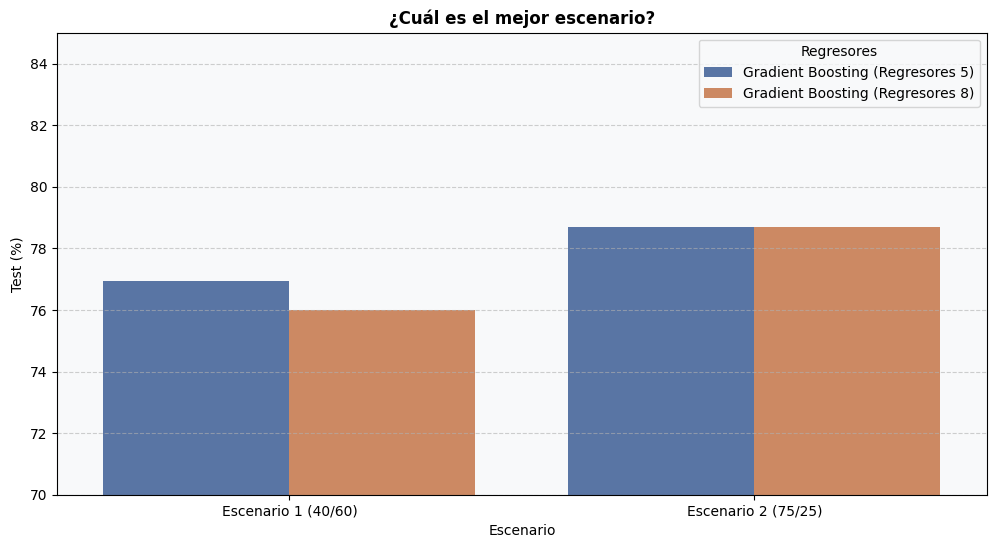

In [ ]:
# Gráfico para identificar visualmente el mejor
plt.figure(figsize=(12, 6))
sns.barplot(data=Churn_final, x="Escenario", y="Test (%)", hue="Regresores", palette=['#4C72B0', '#DD8452'])
plt.title("¿Cuál es el mejor escenario?", fontsize=12, fontweight='bold')
plt.ylim(70, 85)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

---
## Análisis de Resultados y Acciones

*   Elemento de la lista
*   Elemento de la lista

Estratégicas

### 1. Análisis del Mejor Modelo

Tras evaluar los diferentes modelos y escenarios presentados en la `Tabla Comparativa`, hemos determinado que el **'Gradient Boosting (Regresores 5)' en el 'Escenario 2 (75/25)'** es el mejor modelo para explicar la rotación de clientes ('Churn_Yes').

**¿Por qué este es el mejor modelo?**

*   **Alto Accuracy en Test:** Este modelo alcanza un `Test (%)` del **78.68%**, lo que indica que es capaz de predecir correctamente el churn en datos no vistos en casi 8 de cada 10 ocasiones. Esta es una tasa de precisión sólida para la identificación de clientes en riesgo.
*   **Bajo `Overfitting`:** Con una brecha de `Overfitting` del **17.99%**, este modelo presenta el menor sobreajuste entre las opciones que alcanzan la máxima precisión en prueba. Un `Overfitting` más bajo es crucial, ya que significa que el modelo es más robusto y generalizable; es decir, su rendimiento es más consistente entre los datos de entrenamiento y los datos nuevos y reales. Un modelo con menos sobreajuste es menos propenso a errores cuando se aplica en la práctica.

Aunque el 'Gradient Boosting (Regresores 8)' en el mismo escenario obtiene el mismo `Test (%)`, su `Overfitting` es mayor (21.24%), lo que lo hace menos deseable debido a su menor capacidad de generalización y mayor complejidad sin un beneficio adicional en la precisión de prueba. Por lo tanto, priorizamos la simplicidad y la robustez que ofrece el modelo de 5 regresores.

### 2. Accionables Clave Basados en los 5 Regresores Principales

La información de los 5 regresores principales de nuestro mejor modelo es fundamental para diseñar estrategias de negocio efectivas. A continuación, se detallan los regresores y los accionables sugeridos para mitigar o gestionar la tasa de churn:

1.  **`Contract_Month-to-month` (Contrato Mensual)**
    *   **Impacto:** Es el factor más correlacionado positivamente con el churn. Los clientes con contratos mensuales tienen un compromiso bajo y son más propensos a cambiar de proveedor.
    *   **Accionables:**
        *   **Estrategia de Venta Cruzada y Migración de Contrato:** Ofrecer incentivos atractivos (ej. descuentos en el servicio, un mes gratis, o incluso un descuento en electrodomésticos o dispositivos si contratan un plan por 12 o 24 meses) a los clientes con contrato mensual para que migren a contratos de mayor duración. Comunicar claramente los ahorros a largo plazo.
        *   **Programas de Lealtad por Permanencia:** Crear un programa donde los clientes mensuales reciban beneficios incrementales (ej. mejoras de velocidad, acceso a contenido premium, descuentos progresivos) si mantienen su servicio por un determinado número de meses, fomentando el compromiso sin la rigidez de un contrato.

2.  **`tenure` (Antigüedad del Cliente)**
    *   **Impacto:** Correlación negativa fuerte con el churn. Los clientes con baja antigüedad son más propensos a irse, mientras que los de alta antigüedad son más leales.
    *   **Accionables:**
        *   **Campañas de Fidelización Temprana:** Implementar programas de 'onboarding' robustos para nuevos clientes, incluyendo comunicaciones proactivas, encuestas de satisfacción en los primeros 3 y 6 meses, y resolución rápida de problemas iniciales. Ofrecer un bono de descuento o un pequeño regalo (ej. auriculares, un dispositivo smart home) a los 6 meses de permanencia.
        *   **Reconocimiento a la Lealtad:** Para clientes con alta antigüedad, desarrollar programas de reconocimiento y recompensa. Esto podría incluir bonos de descuento en nuestros productos o servicios adicionales, acceso prioritario a soporte técnico, ofertas exclusivas o un nivel de servicio "VIP" que les haga sentir valorados.

3.  **`OnlineSecurity_No` (No Contrató Seguridad Online)**
    *   **Impacto:** Correlación positiva con el churn. Los clientes que no tienen el servicio de seguridad online son más propensos a la rotación.
    *   **Accionables:**
        *   **Educación y Pruebas Gratuitas:** Lanzar campañas educativas sobre la importancia de la seguridad online y los riesgos asociados a su ausencia. Ofrecer a los clientes que no lo tienen una prueba gratuita del servicio de seguridad online por 1-3 meses, permitiéndoles experimentar su valor sin compromiso.
        *   **Paquetes de Valor Agregado:** Integrar el servicio de seguridad online en paquetes de servicios más amplios a un precio preferencial. Esto lo posiciona como una solución completa y no un extra, aumentando la percepción de valor y la retención.

4.  **`InternetService_Fiber optic` (Servicio de Internet Fibra Óptica)**
    *   **Impacto:** Correlación positiva. A pesar de ser un servicio de alta gama, los clientes de fibra óptica tienen una mayor propensión a churn, lo que sugiere posibles problemas de satisfacción o altas expectativas.
    *   **Accionables:**
        *   **Monitoreo y Soporte Proactivo:** Establecer un sistema de monitoreo constante de la calidad del servicio de fibra óptica y un equipo de soporte técnico especializado con tiempos de respuesta rápidos. Implementar un contacto proactivo con clientes de fibra óptica después de incidentes o interrupciones para asegurar su satisfacción.
        *   **Encuestas de Satisfacción Dirigidas:** Realizar encuestas de satisfacción específicas y frecuentes a los clientes de fibra óptica, preguntando sobre la velocidad percibida, estabilidad de la conexión y experiencia general. Utilizar esta retroalimentación para identificar y corregir puntos débiles del servicio.

5.  **`Contract_Two year` (Contrato de Dos Años)**
    *   **Impacto:** Correlación negativa fuerte. Estos clientes muestran una alta lealtad y muy baja propensión a churn.
    *   **Accionables:**
        *   **Análisis de Atributos de Valor:** Investigar y comprender a fondo las motivaciones y beneficios percibidos por los clientes que eligen contratos de dos años. Esta información puede ser utilizada para fortalecer la propuesta de valor de este tipo de contratos y promoverla activamente a otros segmentos.
        *   **Comunicación de Estabilidad y Beneficios:** Continuar destacando los beneficios de los contratos a largo plazo (ej. estabilidad de tarifas, protección contra aumentos, servicios adicionales incluidos) en todas las comunicaciones de marketing. Utilizar testimonios de clientes satisfechos con contratos de dos años para reforzar la confianza y el compromiso.